# 06 Geographically Weighted Regression

This notebook estimates the geographically weighted regression model, compares it with the equivalent global OLS specification, evaluates residual spatial autocorrelation and local collinearity, and maps local coefficients and corrected significance.


## 1. Setup

### 1.1 Import packages and set paths

In [1]:
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from matplotlib.colors import (
    LinearSegmentedColormap,
    ListedColormap,
    TwoSlopeNorm,
)
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor,
)
from libpysal.weights import KNN
from esda.moran import Moran

try:
    from mgwr.gwr import GWR
    from mgwr.sel_bw import Sel_BW
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "The 'mgwr' package is required. Run `%pip install mgwr`, "
        "restart the kernel, and rerun this notebook."
    ) from exc


warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)


# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

# All notebooks and raw data are in the same folder
PROJECT_ROOT = Path(".")

# Outputs generated by previous notebooks
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"

# Creating FIG_DIR also creates OUTPUT_DIR when required
FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Dataset generated by Notebook 05
MSOA_ANALYSIS_PATH = (
    OUTPUT_DIR
    / "05_msoa_spatial_analysis.gpkg"
)

# Boundary file stored beside the notebooks
BOROUGH_PATH = (
    PROJECT_ROOT
    / "London_Boroughs.gpkg"
)

print(
    "MSOA analysis dataset:",
    MSOA_ANALYSIS_PATH.exists(),
)

print(
    "Borough boundary:",
    BOROUGH_PATH.exists(),
)


# ---------------------------------------------------------
# Package versions
# ---------------------------------------------------------

for package_name in [
    "mgwr",
    "geopandas",
    "libpysal",
    "esda",
    "statsmodels",
    "scikit-learn",
]:
    try:
        print(
            f"{package_name}:",
            version(package_name),
        )
    except PackageNotFoundError:
        print(
            f"{package_name}: version not available"
        )

MSOA analysis dataset: True
Borough boundary: True
mgwr: 2.2.1
geopandas: 1.1.2
libpysal: 4.14.1
esda: 2.8.1
statsmodels: 0.14.6
scikit-learn: 1.8.0


### 1.2 Reproducibility and model settings

The main specification matches Model 4 in notebook 05:

\[
\log(1+\mathrm{Housing\ units}_i)
=
eta_0
+eta_1\mathrm{Accessible\ PTAL\ share}_i
+eta_2\mathrm{IMD\ score}_i
+eta_3\log(\mathrm{Area}_i)
+arepsilon_i
\]

The explanatory variables are standardised before GWR so that their scales do not dominate local estimation and the local coefficients are comparable in magnitude. The dependent variable remains in `log1p` housing-unit units.

In [2]:
RANDOM_SEED = 20260802
np.random.seed(RANDOM_SEED)

OUTCOME = "log_housing_units"

PREDICTORS_RAW = [
    "medium_high_ptal_share",
    "mean_imd_score",
    "log_area_km2",
]

PREDICTORS_STANDARDISED = [
    "medium_high_ptal_share_z",
    "mean_imd_score_z",
    "log_area_km2_z",
]

PARAMETER_LABELS = [
    "Intercept",
    "Accessible PTAL share",
    "Mean IMD score",
    "Log MSOA area",
]

KERNEL = "bisquare"
FIXED_BANDWIDTH = False
BANDWIDTH_CRITERION = "AICc"
RESIDUAL_K = 8
PERMUTATIONS = 999

print("Outcome:", OUTCOME)
print("Raw predictors:", PREDICTORS_RAW)
print("Kernel:", KERNEL)
print(
    "Bandwidth type:",
    "fixed distance"
    if FIXED_BANDWIDTH
    else "adaptive nearest neighbours",
)
print(
    "Bandwidth criterion:",
    BANDWIDTH_CRITERION,
)

Outcome: log_housing_units
Raw predictors: ['medium_high_ptal_share', 'mean_imd_score', 'log_area_km2']
Kernel: bisquare
Bandwidth type: adaptive nearest neighbours
Bandwidth criterion: AICc


### 1.3 Plotting and export helpers

In [3]:
def remove_polygon_seams(ax):
    """Remove thin anti-aliasing seams between adjacent polygons."""

    for collection in ax.collections:
        if hasattr(
            collection,
            "set_antialiaseds",
        ):
            collection.set_antialiaseds(
                False
            )

        if hasattr(
            collection,
            "set_linewidths",
        ):
            collection.set_linewidths(
                0
            )

        if hasattr(
            collection,
            "set_edgecolors",
        ):
            collection.set_edgecolors(
                "none"
            )


def add_scale_bar(
    ax,
    length_km=10,
    location=(0.72, 0.04),
    linewidth=4,
):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    bar_length_m = length_km * 1000
    start_x = x0 + (x1 - x0) * location[0]
    start_y = y0 + (y1 - y0) * location[1]
    segment_length = bar_length_m / 2

    ax.plot(
        [
            start_x,
            start_x + segment_length,
        ],
        [
            start_y,
            start_y,
        ],
        color="#333333",
        linewidth=linewidth,
        solid_capstyle="butt",
        zorder=30,
    )

    ax.plot(
        [
            start_x + segment_length,
            start_x + 2 * segment_length,
        ],
        [
            start_y,
            start_y,
        ],
        color="#FFFFFF",
        linewidth=linewidth,
        solid_capstyle="butt",
        zorder=30,
    )

    ax.plot(
        [
            start_x + segment_length,
            start_x + 2 * segment_length,
        ],
        [
            start_y,
            start_y,
        ],
        color="#333333",
        linewidth=1,
        zorder=31,
    )

    label_y = (
        start_y
        - (y1 - y0) * 0.015
    )

    for x_value, label in [
        (
            start_x,
            "0",
        ),
        (
            start_x + segment_length,
            f"{length_km // 2}",
        ),
        (
            start_x + 2 * segment_length,
            f"{length_km} km",
        ),
    ]:
        ax.text(
            x_value,
            label_y,
            label,
            ha="center",
            va="top",
            fontsize=8,
            color="#333333",
            zorder=32,
        )


def add_north_arrow(
    ax,
    location=(0.94, 0.92),
    size=0.05,
):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    centre_x = (
        x0
        + (x1 - x0) * location[0]
    )

    centre_y = (
        y0
        + (y1 - y0) * location[1]
    )

    arrow_length = (
        (y1 - y0)
        * size
    )

    ax.annotate(
        "N",
        xy=(
            centre_x,
            centre_y + arrow_length,
        ),
        xytext=(
            centre_x,
            centre_y,
        ),
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#333333",
        arrowprops={
            "arrowstyle": "-|>",
            "color": "#333333",
            "linewidth": 1.5,
        },
        zorder=30,
    )


def save_figure(filename):
    plt.tight_layout()

    plt.savefig(
        FIG_DIR / filename,
        dpi=400,
        bbox_inches="tight",
        facecolor="#FFFFFF",
        pad_inches=0.18,
    )

    plt.show()


def calculate_aicc(aic, n, k_parameters):
    """Small-sample correction applied to the OLS AIC."""
    return (
        aic
        + (2 * k_parameters * (k_parameters + 1))
        / (n - k_parameters - 1)
    )


def write_geopackage(
    gdf,
    path,
    layer,
):
    """Replace one GeoPackage output cleanly."""

    if path.exists():
        path.unlink()

    gdf.to_file(
        path,
        layer=layer,
        driver="GPKG",
    )

## 2. Load and verify the MSOA analytical dataset

### 2.1 Load notebook 05 output

This section deliberately reuses the final MSOA file rather than rebuilding housing, PTAL and deprivation variables. It therefore preserves the exact analytical geography used in the existing correlation, Moran and OLS analyses.

In [4]:
if not MSOA_ANALYSIS_PATH.exists():
    raise FileNotFoundError(
        "Notebook 05 output was not found:\n"
        f"{MSOA_ANALYSIS_PATH}\n\n"
        "Run notebook 05 through its export section first."
    )

msoa_analysis = (
    gpd.read_file(
        MSOA_ANALYSIS_PATH
    )
)

if msoa_analysis.crs is None:
    raise ValueError(
        "The MSOA dataset has no CRS."
    )

msoa_analysis = (
    msoa_analysis
    .to_crs(
        "EPSG:27700"
    )
)

print(
    "Rows loaded:",
    len(msoa_analysis),
)

print(
    "CRS:",
    msoa_analysis.crs,
)

print(
    "Columns:",
    msoa_analysis.columns.tolist(),
)

Rows loaded: 983
CRS: EPSG:27700
Columns: ['msoa11cd', 'housing_units', 'housing_records', 'mean_site_ptal', 'mean_ptal', 'median_ptal', 'medium_high_ptal_share', 'high_ptal_share', 'ptal_grid_cells', 'mean_imd_score', 'median_imd_score', 'mean_imd_rank', 'mean_imd_decile', 'lsoa_count', 'area_km2', 'housing_units_per_km2', 'log_housing_units', 'log_area_km2', 'geometry']


### 2.2 Construct the GWR sample

In [5]:
REQUIRED_COLUMNS = {
    "msoa11cd",
    "log_housing_units",
    "housing_units",
    "medium_high_ptal_share",
    "mean_ptal",
    "mean_imd_score",
    "area_km2",
    "log_area_km2",
    "geometry",
}

missing_columns = (
    REQUIRED_COLUMNS
    .difference(
        msoa_analysis.columns
    )
)

if missing_columns:
    raise ValueError(
        "The notebook 05 output is missing: "
        f"{sorted(missing_columns)}"
    )

gwr_gdf = (
    msoa_analysis[
        [
            "msoa11cd",
            "log_housing_units",
            "housing_units",
            "medium_high_ptal_share",
            "mean_ptal",
            "mean_imd_score",
            "area_km2",
            "log_area_km2",
            "geometry",
        ]
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna(
        subset=[
            "log_housing_units",
            "mean_ptal",
            "medium_high_ptal_share",
            "mean_imd_score",
            "log_area_km2",
            "geometry",
        ]
    )
    .copy()
)

gwr_gdf = gwr_gdf[
    gwr_gdf.geometry.notna()
    & ~gwr_gdf.geometry.is_empty
].copy()

gwr_gdf = (
    gwr_gdf
    .sort_values(
        "msoa11cd"
    )
    .reset_index(
        drop=True
    )
)

if gwr_gdf[
    "msoa11cd"
].duplicated().any():
    duplicates = (
        gwr_gdf.loc[
            gwr_gdf[
                "msoa11cd"
            ].duplicated(
                keep=False
            ),
            "msoa11cd",
        ]
        .tolist()
    )

    raise ValueError(
        "Duplicate MSOA codes were found: "
        f"{duplicates[:10]}"
    )

EXPECTED_MODEL_4_N = 983

if len(gwr_gdf) != EXPECTED_MODEL_4_N:
    warnings.warn(
        "The GWR sample contains "
        f"{len(gwr_gdf)} observations rather than "
        f"the expected {EXPECTED_MODEL_4_N}. "
        "Check that notebook 05 and this notebook use "
        "the same input files and missing-value rules."
    )

sample_check = pd.DataFrame(
    {
        "measure": [
            "MSOA observations",
            "Unique MSOA codes",
            "Total housing units",
            "Minimum housing units",
            "Maximum housing units",
            "Missing geometries",
        ],
        "value": [
            len(gwr_gdf),
            gwr_gdf[
                "msoa11cd"
            ].nunique(),
            gwr_gdf[
                "housing_units"
            ].sum(),
            gwr_gdf[
                "housing_units"
            ].min(),
            gwr_gdf[
                "housing_units"
            ].max(),
            gwr_gdf.geometry.isna().sum(),
        ],
    }
)

sample_check.to_csv(
    OUTPUT_DIR
    / "06_gwr_sample_check.csv",
    index=False,
)

display(sample_check)

,measure,value
0,MSOA observations,983.0
1,Unique MSOA codes,983.0
2,Total housing units,225104.0
3,Minimum housing units,0.0
4,Maximum housing units,5032.0
5,Missing geometries,0.0


### 2.3 Prepare centroid coordinates

Coordinates are derived from MSOA polygon centroids in British National Grid metres. `spherical=False` is therefore used in bandwidth selection and model estimation.

In [6]:
centroids = (
    gwr_gdf
    .geometry
    .centroid
)

coordinates_array = np.column_stack(
    [
        centroids.x.to_numpy(),
        centroids.y.to_numpy(),
    ]
)

coordinates = [
    tuple(row)
    for row in coordinates_array
]

if (
    pd.DataFrame(
        coordinates_array,
        columns=[
            "x",
            "y",
        ],
    )
    .duplicated()
    .any()
):
    warnings.warn(
        "At least two MSOAs have identical centroid coordinates. "
        "Inspect these before relying on a very small bandwidth."
    )

print(
    "Coordinate array shape:",
    coordinates_array.shape,
)

print(
    "X range:",
    (
        coordinates_array[
            :,
            0,
        ].min(),
        coordinates_array[
            :,
            0,
        ].max(),
    ),
)

print(
    "Y range:",
    (
        coordinates_array[
            :,
            1,
        ].min(),
        coordinates_array[
            :,
            1,
        ].max(),
    ),
)

Coordinate array shape: (983, 2)
X range: (np.float64(505153.20731932216), np.float64(559066.603396432))
Y range: (np.float64(157493.75336846407), np.float64(199517.21589828344))


### 2.4 Load optional borough boundaries for map interpretation

In [7]:
boroughs = None

if BOROUGH_PATH.exists():
    boroughs = (
        gpd.read_file(
            BOROUGH_PATH
        )
        .to_crs(
            gwr_gdf.crs
        )
    )

    boroughs = boroughs[
        boroughs.geometry.notna()
        & ~boroughs.geometry.is_empty
    ].copy()

    print(
        "Borough polygons loaded:",
        len(boroughs),
    )
else:
    print(
        "Borough file not found. "
        "GWR maps will use only the London outline."
    )

london_outline = (
    gwr_gdf
    .dissolve()
)

Borough polygons loaded: 33


## 3. Global OLS baseline and variable preparation

### 3.1 Reproduce the raw Model 4 specification

This is the same substantive specification used in notebook 05. HC3 standard errors are retained for the coefficient table. Model fit is unchanged by the robust covariance estimator.

In [8]:
y = (
    gwr_gdf[
        OUTCOME
    ]
    .astype(float)
    .to_numpy()
    .reshape(
        (-1, 1)
    )
)

X_raw_df = (
    gwr_gdf[
        PREDICTORS_RAW
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .astype(float)
)

X_raw_with_constant = (
    sm.add_constant(
        X_raw_df,
        has_constant="add",
    )
)

ols_raw = (
    sm.OLS(
        y.flatten(),
        X_raw_with_constant,
    )
    .fit(
        cov_type="HC3"
    )
)

print(
    ols_raw.summary()
)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.161
Method:                 Least Squares   F-statistic:                     59.33
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           3.04e-35
Time:                        12:32:32   Log-Likelihood:                -1522.2
No. Observations:                 983   AIC:                             3052.
Df Residuals:                     979   BIC:                             3072.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      3

In [9]:
raw_confidence_intervals = (
    ols_raw
    .conf_int()
)

raw_ols_table = pd.DataFrame(
    {
        "term": (
            X_raw_with_constant
            .columns
        ),
        "coefficient": (
            ols_raw
            .params
            .to_numpy()
        ),
        "hc3_standard_error": (
            ols_raw
            .bse
            .to_numpy()
        ),
        "t_value": (
            ols_raw
            .tvalues
            .to_numpy()
        ),
        "p_value": (
            ols_raw
            .pvalues
            .to_numpy()
        ),
        "ci_95_lower": (
            raw_confidence_intervals[
                0
            ]
            .to_numpy()
        ),
        "ci_95_upper": (
            raw_confidence_intervals[
                1
            ]
            .to_numpy()
        ),
    }
)

raw_ols_table.to_csv(
    OUTPUT_DIR
    / "06_global_ols_raw_coefficients.csv",
    index=False,
)

display(
    raw_ols_table.round(4)
)

,term,coefficient,hc3_standard_error,t_value,p_value,ci_95_lower,ci_95_upper
0,const,3.4206,0.1214,28.1860,0.0000,3.1828,3.6585
1,medium_high_ptal_share,1.8676,0.1486,12.5650,0.0000,1.5763,2.1589
2,mean_imd_score,0.0114,0.0044,2.6049,0.0092,0.0028,0.0200
3,log_area_km2,0.6942,0.0812,8.5542,0.0000,0.5351,0.8533


### 3.2 Global multicollinearity check

In [10]:
vif_design = sm.add_constant(
    X_raw_df,
    has_constant="add",
)

global_vif_rows = []

for column_index, variable_name in enumerate(
    vif_design.columns
):
    if variable_name == "const":
        continue

    global_vif_rows.append(
        {
            "variable": variable_name,
            "VIF": (
                variance_inflation_factor(
                    vif_design.values,
                    column_index,
                )
            ),
        }
    )

global_vif_table = pd.DataFrame(
    global_vif_rows
)

global_vif_table.to_csv(
    OUTPUT_DIR
    / "06_global_vif.csv",
    index=False,
)

display(
    global_vif_table.round(3)
)

,variable,VIF
0,medium_high_ptal_share,1.860
1,mean_imd_score,1.143
2,log_area_km2,1.924


### 3.3 Standardise explanatory variables

Each predictor is converted to a z-score. The local coefficient for a predictor therefore represents the change in `log1p` completed housing units associated with a one-standard-deviation increase in that predictor, conditional on the other variables.

In [11]:
scaler = StandardScaler()

X_standardised_array = (
    scaler.fit_transform(
        X_raw_df
    )
)

for index, column in enumerate(
    PREDICTORS_STANDARDISED
):
    gwr_gdf[
        column
    ] = (
        X_standardised_array[
            :,
            index,
        ]
    )

scaling_table = pd.DataFrame(
    {
        "raw_variable": PREDICTORS_RAW,
        "standardised_variable": (
            PREDICTORS_STANDARDISED
        ),
        "mean_used_for_scaling": (
            scaler.mean_
        ),
        "standard_deviation_used_for_scaling": (
            scaler.scale_
        ),
    }
)

scaling_table.to_csv(
    OUTPUT_DIR
    / "06_gwr_variable_scaling.csv",
    index=False,
)

display(
    scaling_table.round(6)
)

display(
    gwr_gdf[
        PREDICTORS_STANDARDISED
    ]
    .describe()
    .T
    .round(4)
)

,raw_variable,standardised_variable,mean_used_for_scaling,standard_deviation_used_for_scaling
0,medium_high_ptal_share,medium_high_ptal_share_z,0.461288,0.351301
1,mean_imd_score,mean_imd_score_z,21.563737,9.448538
2,log_area_km2,log_area_km2_z,0.180554,0.683394


,count,mean,std,min,25%,50%,75%,max
medium_high_ptal_share_z,983.0,0.0,1.0005,-1.3131,-0.9561,-0.1338,0.9814,1.5335
mean_imd_score_z,983.0,-0.0,1.0005,-1.8523,-0.8273,-0.0387,0.7604,3.0543
log_area_km2_z,983.0,0.0,1.0005,-2.0564,-0.7542,-0.0648,0.5581,4.2884


### 3.4 Standardised OLS comparison model

The fitted values and overall fit are identical to the raw OLS model. Only the coefficient scale changes. This version provides a direct global comparison with the standardised local GWR coefficients.

In [12]:
X_gwr = (
    gwr_gdf[
        PREDICTORS_STANDARDISED
    ]
    .astype(float)
    .to_numpy()
)

X_standardised_with_constant = (
    sm.add_constant(
        X_gwr,
        has_constant="add",
    )
)

ols_standardised = (
    sm.OLS(
        y.flatten(),
        X_standardised_with_constant,
    )
    .fit(
        cov_type="HC3"
    )
)

standardised_ols_terms = [
    "Intercept",
    *PARAMETER_LABELS[1:],
]

standardised_ols_table = pd.DataFrame(
    {
        "term": standardised_ols_terms,
        "coefficient": (
            np.asarray(
                ols_standardised.params
            )
        ),
        "hc3_standard_error": (
            np.asarray(
                ols_standardised.bse
            )
        ),
        "t_value": (
            np.asarray(
                ols_standardised.tvalues
            )
        ),
        "p_value": (
            np.asarray(
                ols_standardised.pvalues
            )
        ),
    }
)

standardised_ols_table.to_csv(
    OUTPUT_DIR
    / "06_global_ols_standardised_coefficients.csv",
    index=False,
)

display(
    standardised_ols_table.round(4)
)

print(
    "Raw OLS R-squared:",
    round(
        ols_raw.rsquared,
        4,
    ),
)

print(
    "Standardised OLS R-squared:",
    round(
        ols_standardised.rsquared,
        4,
    ),
)

,term,coefficient,hc3_standard_error,t_value,p_value
0,Intercept,4.6531,0.0365,127.5992,0.0000
1,Accessible PTAL share,0.6561,0.0522,12.5650,0.0000
2,Mean IMD score,0.1076,0.0413,2.6049,0.0092
3,Log MSOA area,0.4744,0.0555,8.5542,0.0000


Raw OLS R-squared: 0.1631
Standardised OLS R-squared: 0.1631


## 4. Select the GWR bandwidth

An **adaptive bi-square kernel** is used because MSOA centroids are more densely packed in some parts of London than others. The selected bandwidth is therefore interpreted as the number of nearest observations contributing to each local regression, with more distant observations receiving progressively smaller weights and observations outside the bandwidth receiving zero weight.

In [13]:
bandwidth_selector = Sel_BW(
    coordinates,
    y,
    X_gwr,
    kernel=KERNEL,
    fixed=FIXED_BANDWIDTH,
    constant=True,
    spherical=False,
)

selected_bandwidth = (
    bandwidth_selector
    .search(
        criterion=(
            BANDWIDTH_CRITERION
        )
    )
)

bandwidth_table = pd.DataFrame(
    {
        "setting": [
            "Kernel",
            "Fixed bandwidth",
            "Selection criterion",
            "Selected bandwidth",
            "Observations",
        ],
        "value": [
            KERNEL,
            FIXED_BANDWIDTH,
            BANDWIDTH_CRITERION,
            selected_bandwidth,
            len(gwr_gdf),
        ],
    }
)

bandwidth_table.to_csv(
    OUTPUT_DIR
    / "06_gwr_bandwidth.csv",
    index=False,
)

display(
    bandwidth_table
)

if not FIXED_BANDWIDTH:
    print(
        "Interpretation: each local regression uses an adaptive "
        f"bandwidth of approximately {int(round(selected_bandwidth))} "
        "nearest MSOA centroids."
    )

,setting,value
0,Kernel,bisquare
1,Fixed bandwidth,False
2,Selection criterion,AICc
3,Selected bandwidth,124.0
4,Observations,983


Interpretation: each local regression uses an adaptive bandwidth of approximately 124 nearest MSOA centroids.


## 5. Estimate the GWR model

In [14]:
gwr_model = GWR(
    coordinates,
    y,
    X_gwr,
    bw=selected_bandwidth,
    kernel=KERNEL,
    fixed=FIXED_BANDWIDTH,
    constant=True,
    spherical=False,
    sigma2_v1=True,
    hat_matrix=False,
)

gwr_results = (
    gwr_model
    .fit()
)

gwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                 983
Number of covariates:                                                     4

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                           1273.818
Log-likelihood:                                                   -1522.196
AIC:                                                               3052.392
AICc:                                                              3054.454
BIC:                                                              -5472.088
R2:                                                                   0.163
Adj. R2:                                                              0.161

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

## 6. Compare global OLS and GWR

### 6.1 Model-fit comparison

A lower AICc indicates a better balance between fit and model complexity. GWR should not be preferred solely because its \(R^2\) is higher; residual spatial autocorrelation, local collinearity and coefficient stability also need to be checked.

In [15]:
ols_parameter_count = int(
    ols_standardised.df_model
    + 1
)

ols_aicc = calculate_aicc(
    aic=ols_standardised.aic,
    n=int(
        ols_standardised.nobs
    ),
    k_parameters=(
        ols_parameter_count
    ),
)

model_comparison = pd.DataFrame(
    [
        {
            "model": "Global OLS",
            "n": int(
                ols_standardised.nobs
            ),
            "r_squared": (
                ols_standardised.rsquared
            ),
            "adjusted_r_squared": (
                ols_standardised.rsquared_adj
            ),
            "aic": (
                ols_standardised.aic
            ),
            "aicc": ols_aicc,
            "bic": (
                ols_standardised.bic
            ),
            "effective_parameters": (
                ols_parameter_count
            ),
            "residual_sum_of_squares": (
                np.sum(
                    np.square(
                        ols_standardised.resid
                    )
                )
            ),
        },
        {
            "model": "GWR",
            "n": int(
                gwr_results.n
            ),
            "r_squared": float(
                gwr_results.R2
            ),
            "adjusted_r_squared": float(
                gwr_results.adj_R2
            ),
            "aic": float(
                gwr_results.aic
            ),
            "aicc": float(
                gwr_results.aicc
            ),
            "bic": float(
                gwr_results.bic
            ),
            "effective_parameters": float(
                gwr_results.ENP
            ),
            "residual_sum_of_squares": float(
                gwr_results.resid_ss
            ),
        },
    ]
)

model_comparison[
    "delta_aicc_from_ols"
] = (
    model_comparison[
        "aicc"
    ]
    - model_comparison.loc[
        model_comparison[
            "model"
        ] == "Global OLS",
        "aicc",
    ].iloc[0]
)

model_comparison.to_csv(
    OUTPUT_DIR
    / "06_ols_gwr_model_comparison.csv",
    index=False,
)

display(
    model_comparison.round(4)
)

,model,n,r_squared,adjusted_r_squared,aic,aicc,bic,effective_parameters,residual_sum_of_squares,delta_aicc_from_ols
0,Global OLS,983,0.1631,0.1605,3052.3924,3052.4333,3071.9548,4.0000,1273.8183,0.0000
1,GWR,983,0.3582,0.3011,2946.0399,2960.8984,3343.6627,80.3033,976.8195,-91.5349


### 6.2 Residual Moran's I

The same symmetrised, row-standardised eight-nearest-neighbour structure used in notebook 05 is applied to both OLS and GWR residuals. A reduction in residual Moran's I would indicate that GWR captures part of the spatial structure left unexplained by the global model.

In [16]:
residual_weights = KNN.from_dataframe(
    gwr_gdf,
    k=RESIDUAL_K,
    use_index=True,
)

residual_weights = (
    residual_weights
    .symmetrize()
)

residual_weights.transform = "r"

ols_residuals = (
    np.asarray(
        ols_standardised.resid
    )
    .flatten()
)

gwr_residuals = (
    np.asarray(
        gwr_results.resid_response
    )
    .flatten()
)

np.random.seed(
    RANDOM_SEED
)

ols_residual_moran = Moran(
    ols_residuals,
    residual_weights,
    permutations=PERMUTATIONS,
)

np.random.seed(
    RANDOM_SEED
)

gwr_residual_moran = Moran(
    gwr_residuals,
    residual_weights,
    permutations=PERMUTATIONS,
)

residual_moran_table = pd.DataFrame(
    [
        {
            "model": "Global OLS",
            "k_nearest_neighbours": (
                RESIDUAL_K
            ),
            "morans_i": (
                ols_residual_moran.I
            ),
            "expected_i": (
                ols_residual_moran.EI
            ),
            "pseudo_p_value": (
                ols_residual_moran.p_sim
            ),
            "z_score": (
                ols_residual_moran.z_sim
            ),
        },
        {
            "model": "GWR",
            "k_nearest_neighbours": (
                RESIDUAL_K
            ),
            "morans_i": (
                gwr_residual_moran.I
            ),
            "expected_i": (
                gwr_residual_moran.EI
            ),
            "pseudo_p_value": (
                gwr_residual_moran.p_sim
            ),
            "z_score": (
                gwr_residual_moran.z_sim
            ),
        },
    ]
)

residual_moran_table.to_csv(
    OUTPUT_DIR
    / "06_ols_gwr_residual_morans_i.csv",
    index=False,
)

display(
    residual_moran_table.round(4)
)

,model,k_nearest_neighbours,morans_i,expected_i,pseudo_p_value,z_score
0,Global OLS,8,0.1645,-0.001,0.001,11.3379
1,GWR,8,0.0323,-0.001,0.011,2.2613


## 7. Build the local GWR results dataset

### 7.1 Coefficients, uncertainty, local fit and residual diagnostics

The corrected critical \(t\)-value supplied by `mgwr` is used for the local significance flags. This adjustment is preferable to applying an uncorrected \(p<0.05\) rule independently at every MSOA.

In [17]:
parameter_suffixes = [
    "intercept",
    "ptal",
    "imd",
    "area",
]

parameter_estimates = np.asarray(
    gwr_results.params
)

parameter_standard_errors = np.asarray(
    gwr_results.bse
)

parameter_t_values = np.asarray(
    gwr_results.tvalues
)

corrected_critical_t = float(
    np.asarray(
        gwr_results.critical_tval()
    )
    .squeeze()
)

filtered_t_values = np.asarray(
    gwr_results.filter_tvals()
)

gwr_result_gdf = (
    gwr_gdf
    .copy()
)

for index, suffix in enumerate(
    parameter_suffixes
):
    gwr_result_gdf[
        f"gwr_beta_{suffix}"
    ] = (
        parameter_estimates[
            :,
            index,
        ]
    )

    gwr_result_gdf[
        f"gwr_se_{suffix}"
    ] = (
        parameter_standard_errors[
            :,
            index,
        ]
    )

    gwr_result_gdf[
        f"gwr_t_{suffix}"
    ] = (
        parameter_t_values[
            :,
            index,
        ]
    )

    gwr_result_gdf[
        f"gwr_sig_{suffix}"
    ] = (
        np.abs(
            parameter_t_values[
                :,
                index,
            ]
        )
        >= corrected_critical_t
    )

    gwr_result_gdf[
        f"gwr_filtered_t_{suffix}"
    ] = (
        filtered_t_values[
            :,
            index,
        ]
    )

gwr_result_gdf[
    "gwr_predicted"
] = (
    np.asarray(
        gwr_results.predy
    )
    .flatten()
)

gwr_result_gdf[
    "gwr_residual"
] = (
    gwr_residuals
)

gwr_result_gdf[
    "gwr_standardised_residual"
] = (
    np.asarray(
        gwr_results.std_res
    )
    .flatten()
)

gwr_result_gdf[
    "gwr_local_r2"
] = (
    np.asarray(
        gwr_results.localR2
    )
    .flatten()
)

gwr_result_gdf[
    "gwr_leverage"
] = (
    np.asarray(
        gwr_results.influ
    )
    .flatten()
)

gwr_result_gdf[
    "gwr_cooks_d"
] = (
    np.asarray(
        gwr_results.cooksD
    )
    .flatten()
)

print(
    "Corrected critical t-value:",
    round(
        corrected_critical_t,
        4,
    ),
)

display(
    gwr_result_gdf[
        [
            "gwr_beta_ptal",
            "gwr_beta_imd",
            "gwr_beta_area",
            "gwr_local_r2",
            "gwr_residual",
            "gwr_standardised_residual",
            "gwr_cooks_d",
        ]
    ]
    .describe()
    .T
    .round(4)
)

Corrected critical t-value: 3.0323


,count,mean,std,min,25%,50%,75%,max
gwr_beta_ptal,983.0,0.6257,0.3128,-0.1694,0.4329,0.6432,0.8304,1.4084
gwr_beta_imd,983.0,0.1926,0.1997,-0.3555,0.0388,0.2085,0.3176,0.7137
gwr_beta_area,983.0,0.5672,0.2938,0.0139,0.3440,0.4873,0.7958,1.3161
gwr_local_r2,983.0,0.2897,0.1032,0.0463,0.2066,0.2875,0.3643,0.5187
gwr_residual,983.0,0.0243,0.9971,-3.1634,-0.5835,0.0345,0.6515,3.8929
gwr_standardised_residual,983.0,0.0231,1.0049,-3.2000,-0.5951,0.0351,0.6570,4.0644
gwr_cooks_d,983.0,0.0013,0.0029,0.0000,0.0001,0.0003,0.0012,0.0369


### 7.2 Summarise local coefficient surfaces

In [18]:
coefficient_summary_rows = []

for (
    label,
    suffix,
) in zip(
    PARAMETER_LABELS,
    parameter_suffixes,
):
    coefficient_column = (
        f"gwr_beta_{suffix}"
    )

    significance_column = (
        f"gwr_sig_{suffix}"
    )

    values = (
        gwr_result_gdf[
            coefficient_column
        ]
        .astype(float)
    )

    significant = (
        gwr_result_gdf[
            significance_column
        ]
        .astype(bool)
    )

    coefficient_summary_rows.append(
        {
            "parameter": label,
            "minimum": values.min(),
            "q25": values.quantile(0.25),
            "median": values.median(),
            "mean": values.mean(),
            "q75": values.quantile(0.75),
            "maximum": values.max(),
            "standard_deviation": values.std(),
            "share_positive": (
                values.gt(0).mean()
            ),
            "share_negative": (
                values.lt(0).mean()
            ),
            "corrected_significant_count": (
                significant.sum()
            ),
            "corrected_significant_share": (
                significant.mean()
            ),
        }
    )

coefficient_summary = pd.DataFrame(
    coefficient_summary_rows
)

coefficient_summary.to_csv(
    OUTPUT_DIR
    / "06_gwr_local_coefficient_summary.csv",
    index=False,
)

display(
    coefficient_summary.round(4)
)

,parameter,minimum,q25,median,mean,q75,maximum,standard_deviation,share_positive,share_negative,corrected_significant_count,corrected_significant_share
0,Intercept,3.8925,4.5787,4.8845,4.8373,5.0454,6.0998,0.3999,1.0000,0.0000,983,1.0000
1,Accessible PTAL share,-0.1694,0.4329,0.6432,0.6257,0.8304,1.4084,0.3128,0.9654,0.0346,539,0.5483
2,Mean IMD score,-0.3555,0.0388,0.2085,0.1926,0.3176,0.7137,0.1997,0.8108,0.1892,63,0.0641
3,Log MSOA area,0.0139,0.3440,0.4873,0.5672,0.7958,1.3161,0.2938,1.0000,0.0000,373,0.3795


## 8. Local multicollinearity diagnostics

A global VIF can be low even when local regressions become unstable in particular parts of London. This section calculates local VIFs and local condition numbers. A condition number above 30 is used as a warning flag rather than an automatic rejection rule.

In [19]:
(
    local_correlations,
    local_vifs,
    local_condition_numbers,
    local_variance_decomposition,
) = (
    gwr_results
    .local_collinearity()
)

local_vifs = np.asarray(
    local_vifs
)

local_condition_numbers = (
    np.asarray(
        local_condition_numbers
    )
    .flatten()
)

if local_vifs.shape[1] != len(
    PREDICTORS_STANDARDISED
):
    raise ValueError(
        "Unexpected local VIF shape: "
        f"{local_vifs.shape}. "
        "Check the installed mgwr version."
    )

for index, suffix in enumerate(
    [
        "ptal",
        "imd",
        "area",
    ]
):
    gwr_result_gdf[
        f"gwr_local_vif_{suffix}"
    ] = (
        local_vifs[
            :,
            index,
        ]
    )

gwr_result_gdf[
    "gwr_condition_number"
] = (
    local_condition_numbers
)

gwr_result_gdf[
    "gwr_condition_number_gt30"
] = (
    gwr_result_gdf[
        "gwr_condition_number"
    ]
    > 30
)

local_collinearity_summary = pd.DataFrame(
    [
        {
            "diagnostic": "Local VIF: PTAL",
            "minimum": (
                gwr_result_gdf[
                    "gwr_local_vif_ptal"
                ].min()
            ),
            "median": (
                gwr_result_gdf[
                    "gwr_local_vif_ptal"
                ].median()
            ),
            "maximum": (
                gwr_result_gdf[
                    "gwr_local_vif_ptal"
                ].max()
            ),
            "share_above_5": (
                (
                    gwr_result_gdf[
                        "gwr_local_vif_ptal"
                    ]
                    > 5
                )
                .mean()
            ),
            "share_above_10": (
                (
                    gwr_result_gdf[
                        "gwr_local_vif_ptal"
                    ]
                    > 10
                )
                .mean()
            ),
        },
        {
            "diagnostic": "Local VIF: IMD",
            "minimum": (
                gwr_result_gdf[
                    "gwr_local_vif_imd"
                ].min()
            ),
            "median": (
                gwr_result_gdf[
                    "gwr_local_vif_imd"
                ].median()
            ),
            "maximum": (
                gwr_result_gdf[
                    "gwr_local_vif_imd"
                ].max()
            ),
            "share_above_5": (
                (
                    gwr_result_gdf[
                        "gwr_local_vif_imd"
                    ]
                    > 5
                )
                .mean()
            ),
            "share_above_10": (
                (
                    gwr_result_gdf[
                        "gwr_local_vif_imd"
                    ]
                    > 10
                )
                .mean()
            ),
        },
        {
            "diagnostic": "Local VIF: area",
            "minimum": (
                gwr_result_gdf[
                    "gwr_local_vif_area"
                ].min()
            ),
            "median": (
                gwr_result_gdf[
                    "gwr_local_vif_area"
                ].median()
            ),
            "maximum": (
                gwr_result_gdf[
                    "gwr_local_vif_area"
                ].max()
            ),
            "share_above_5": (
                (
                    gwr_result_gdf[
                        "gwr_local_vif_area"
                    ]
                    > 5
                )
                .mean()
            ),
            "share_above_10": (
                (
                    gwr_result_gdf[
                        "gwr_local_vif_area"
                    ]
                    > 10
                )
                .mean()
            ),
        },
        {
            "diagnostic": "Local condition number",
            "minimum": (
                gwr_result_gdf[
                    "gwr_condition_number"
                ].min()
            ),
            "median": (
                gwr_result_gdf[
                    "gwr_condition_number"
                ].median()
            ),
            "maximum": (
                gwr_result_gdf[
                    "gwr_condition_number"
                ].max()
            ),
            "share_above_5": np.nan,
            "share_above_10": (
                (
                    gwr_result_gdf[
                        "gwr_condition_number"
                    ]
                    > 30
                )
                .mean()
            ),
        },
    ]
)

local_collinearity_summary.to_csv(
    OUTPUT_DIR
    / "06_gwr_local_collinearity_summary.csv",
    index=False,
)

display(
    local_collinearity_summary.round(4)
)

,diagnostic,minimum,median,maximum,share_above_5,share_above_10
0,Local VIF: PTAL,1.0011,1.3110,2.5192,0.0,0.0
1,Local VIF: IMD,1.0001,1.0880,1.5625,0.0,0.0
2,Local VIF: area,1.0253,1.3432,2.5100,0.0,0.0
3,Local condition number,1.4478,3.5500,13.0206,NaN,0.0


## 9. Optional Monte Carlo test of spatial variability

This tests whether each observed coefficient surface varies more across space than would be expected under random spatial rearrangement.

It is computationally demanding because bandwidth selection and local estimation are repeated many times. Keep the flag as `False` while debugging. A preliminary run can use 99 iterations; a final result can use more iterations if runtime permits.

In [20]:
RUN_SPATIAL_VARIABILITY_TEST = True
SPATIAL_VARIABILITY_ITERATIONS = 99

if RUN_SPATIAL_VARIABILITY_TEST:
    spatial_variability_p_values = (
        gwr_results
        .spatial_variability(
            bandwidth_selector,
            n_iters=(
                SPATIAL_VARIABILITY_ITERATIONS
            ),
            seed=RANDOM_SEED,
        )
    )

    spatial_variability_table = pd.DataFrame(
        {
            "parameter": (
                PARAMETER_LABELS
            ),
            "monte_carlo_p_value": (
                spatial_variability_p_values
            ),
            "iterations": (
                SPATIAL_VARIABILITY_ITERATIONS
            ),
        }
    )

    spatial_variability_table.to_csv(
        OUTPUT_DIR
        / "06_gwr_spatial_variability_test.csv",
        index=False,
    )

    display(
        spatial_variability_table.round(4)
    )
else:
    print(
        "Spatial variability test skipped. "
        "Set RUN_SPATIAL_VARIABILITY_TEST = True "
        "after the main model has been checked."
    )

Testing:   0%|          | 0/99 [00:00<?, ?it/s]

,parameter,monte_carlo_p_value,iterations
0,Intercept,0.0,99
1,Accessible PTAL share,0.0,99
2,Mean IMD score,0.0,99
3,Log MSOA area,0.0,99


## 10. GWR maps

The coefficient maps show all local estimates, including locations where the corrected local \(t\)-value does not reach the adjusted threshold. Separate significance maps are exported for PTAL and IMD so that coefficient magnitude and statistical uncertainty are not conflated.

In [21]:
coefficient_cmap = LinearSegmentedColormap.from_list(
    "gwr_coefficient",
    [
        "#2F5C74",
        "#CCDCE3",
        "#F0F0EE",
        "#DDCBB3",
        "#A8442F",
    ],
)

local_r2_cmap = LinearSegmentedColormap.from_list(
    "gwr_local_r2",
    [
        "#F2F2F0",
        "#E1E5E2",
        "#C9D0CB",
        "#AFBBB4",
        "#617B6F",
    ],
)

condition_cmap = LinearSegmentedColormap.from_list(
    "gwr_condition",
    [
        "#F2F2F0",
        "#E4DED3",
        "#CDBFA8",
        "#A9896B",
        "#744D3E",
    ],
)

significance_cmap = ListedColormap(
    [
        "#EDEDEA",
        "#A8442F",
    ]
)


def add_map_boundaries(ax):
    if boroughs is not None:
        boroughs.boundary.plot(
            ax=ax,
            color="#FFFFFF",
            linewidth=0.35,
            alpha=0.85,
            zorder=12,
        )

    london_outline.boundary.plot(
        ax=ax,
        color="#C8C8C8",
        linewidth=0.8,
        zorder=15,
    )


def plot_coefficient_surface(
    column,
    title,
    legend_label,
    filename,
):
    values = (
        gwr_result_gdf[
            column
        ]
        .astype(float)
    )

    limit = float(
        np.nanpercentile(
            np.abs(values),
            98,
        )
    )

    if (
        not np.isfinite(limit)
        or limit <= 0
    ):
        limit = float(
            np.nanmax(
                np.abs(values)
            )
        )

    if (
        not np.isfinite(limit)
        or limit <= 0
    ):
        limit = 1.0

    norm = TwoSlopeNorm(
        vmin=-limit,
        vcenter=0,
        vmax=limit,
    )

    fig, ax = plt.subplots(
        figsize=(10, 10),
        facecolor="#FFFFFF",
    )

    gwr_result_gdf.plot(
        column=column,
        cmap=coefficient_cmap,
        norm=norm,
        legend=True,
        linewidth=0,
        edgecolor="none",
        antialiased=False,
        ax=ax,
        legend_kwds={
            "label": legend_label,
            "shrink": 0.72,
        },
        zorder=5,
    )

    remove_polygon_seams(ax)
    add_map_boundaries(ax)

    ax.set_title(
        title,
        pad=18,
        color="#1A1A1A",
    )

    ax.axis("off")

    add_scale_bar(ax)
    add_north_arrow(ax)

    save_figure(filename)


def plot_significance_surface(
    significance_column,
    title,
    filename,
):
    plot_gdf = (
        gwr_result_gdf
        .copy()
    )

    plot_gdf[
        "significance_numeric"
    ] = (
        plot_gdf[
            significance_column
        ]
        .astype(int)
    )

    fig, ax = plt.subplots(
        figsize=(10, 10),
        facecolor="#FFFFFF",
    )

    plot_gdf.plot(
        column="significance_numeric",
        categorical=True,
        cmap=significance_cmap,
        legend=True,
        linewidth=0,
        edgecolor="none",
        antialiased=False,
        ax=ax,
        legend_kwds={
            "labels": [
                "Not significant",
                "Significant",
            ],
            "loc": "upper right",
            "frameon": False,
            "title": (
                "Corrected local test"
            ),
        },
        zorder=5,
    )

    remove_polygon_seams(ax)
    add_map_boundaries(ax)

    ax.set_title(
        title,
        pad=18,
        color="#1A1A1A",
    )

    ax.axis("off")

    add_scale_bar(ax)
    add_north_arrow(ax)

    save_figure(filename)

### 10.1 Local PTAL coefficient

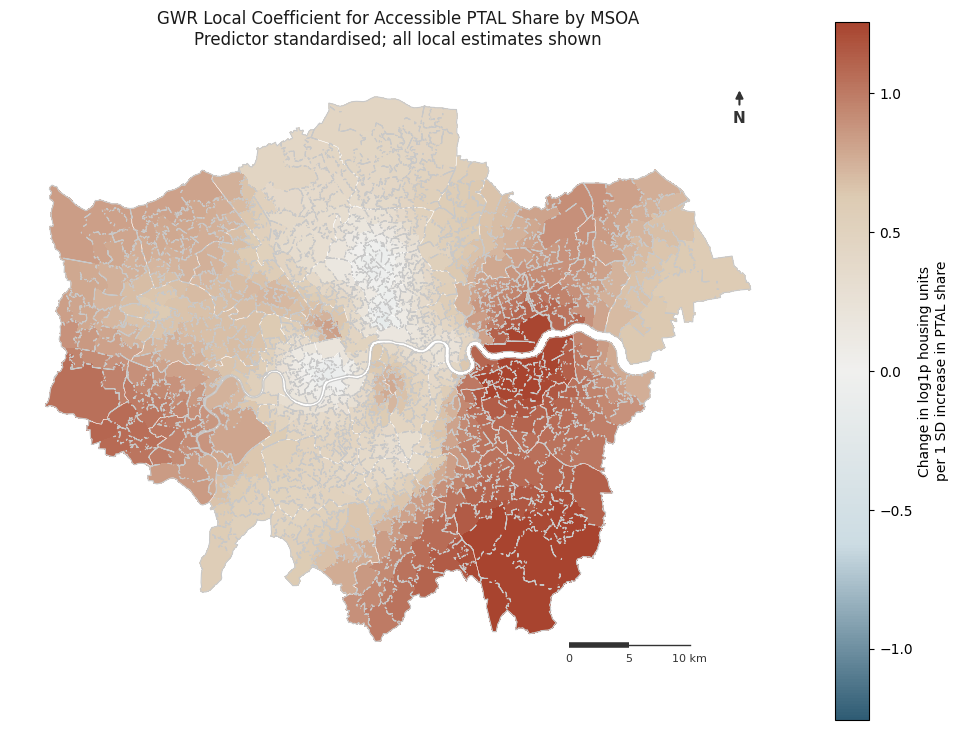

In [22]:
plot_coefficient_surface(
    column="gwr_beta_ptal",
    title=(
        "GWR Local Coefficient for Accessible PTAL Share by MSOA\n"
        "Predictor standardised; all local estimates shown"
    ),
    legend_label=(
        "Change in log1p housing units\n"
        "per 1 SD increase in PTAL share"
    ),
    filename=(
        "fig06a_gwr_ptal_coefficient.png"
    ),
)

### 10.2 Local IMD coefficient

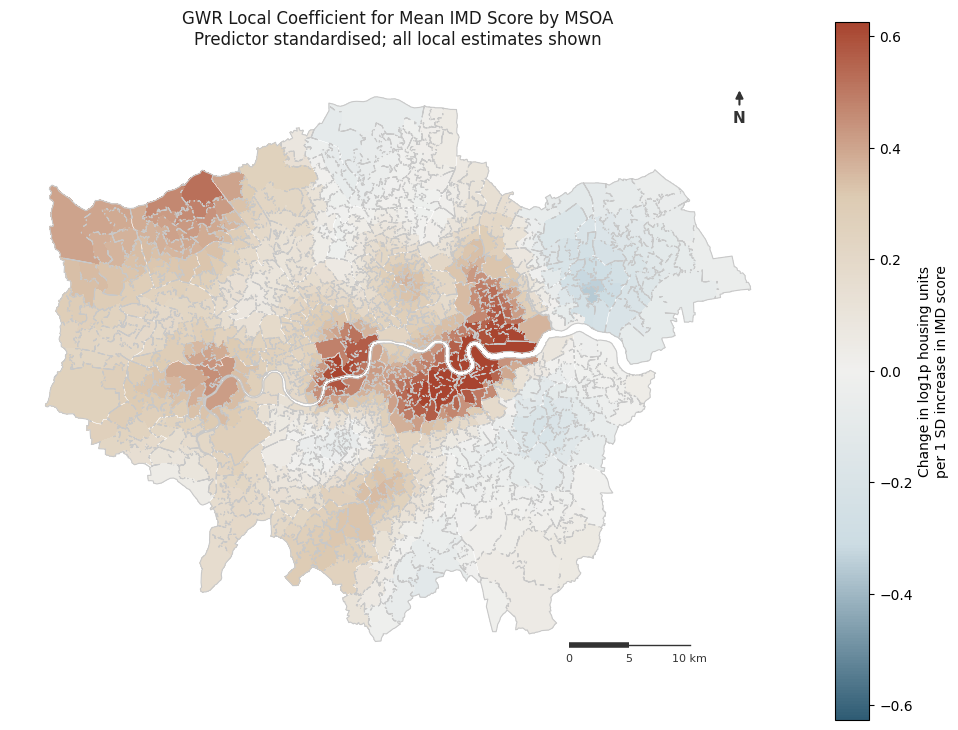

In [23]:
plot_coefficient_surface(
    column="gwr_beta_imd",
    title=(
        "GWR Local Coefficient for Mean IMD Score by MSOA\n"
        "Predictor standardised; all local estimates shown"
    ),
    legend_label=(
        "Change in log1p housing units\n"
        "per 1 SD increase in IMD score"
    ),
    filename=(
        "fig06b_gwr_imd_coefficient.png"
    ),
)

### 10.3 Local area coefficient

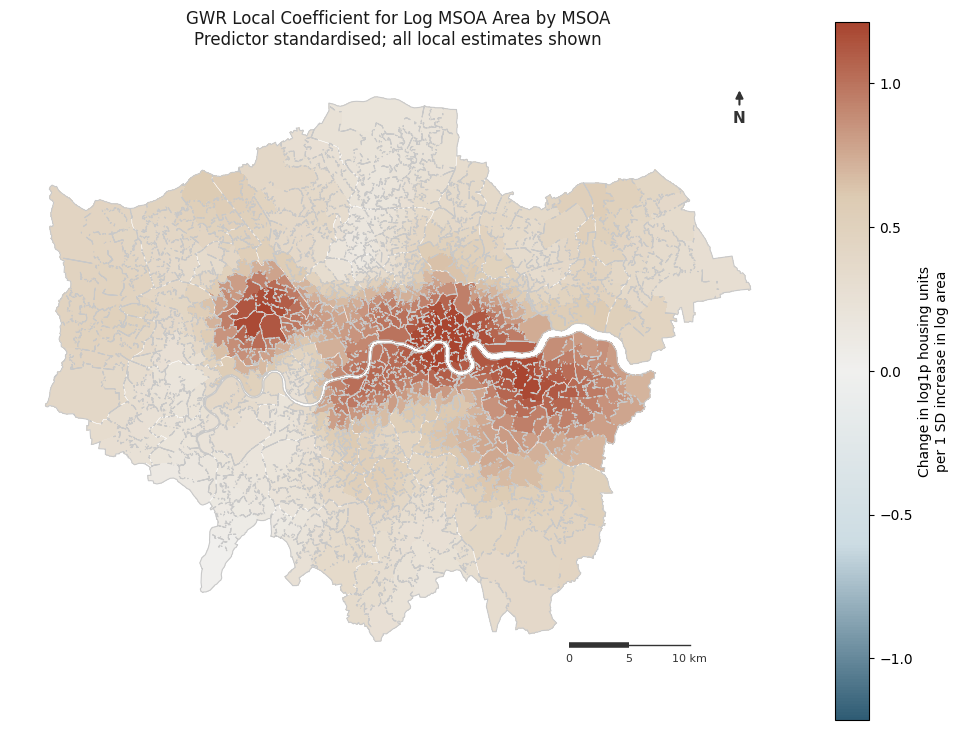

In [24]:
plot_coefficient_surface(
    column="gwr_beta_area",
    title=(
        "GWR Local Coefficient for Log MSOA Area by MSOA\n"
        "Predictor standardised; all local estimates shown"
    ),
    legend_label=(
        "Change in log1p housing units\n"
        "per 1 SD increase in log area"
    ),
    filename=(
        "fig06c_gwr_area_coefficient.png"
    ),
)

### 10.4 Local \(R^2\)

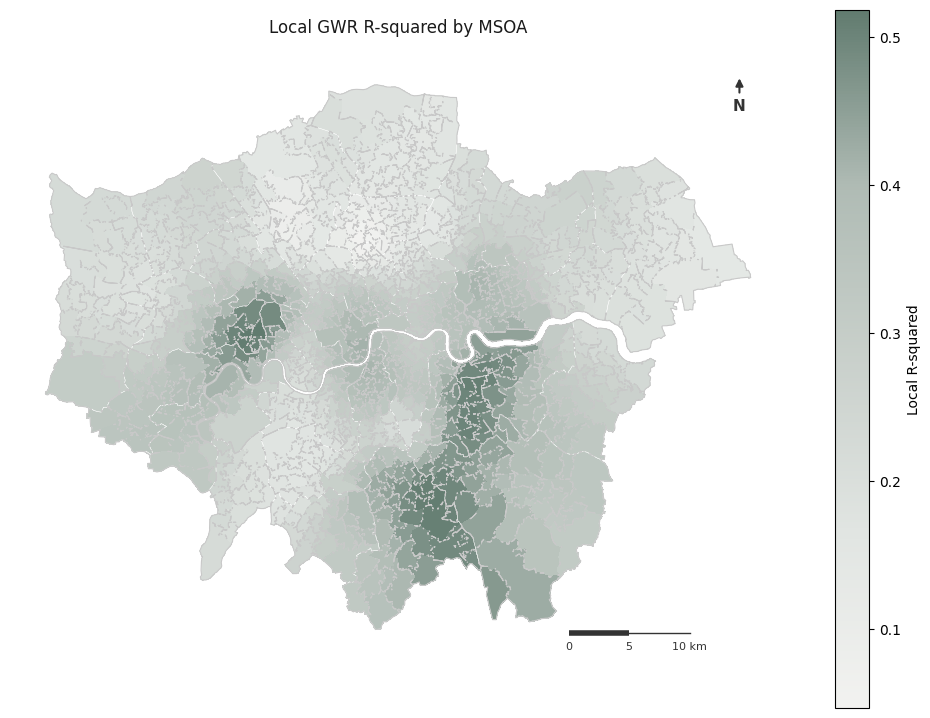

In [25]:
fig, ax = plt.subplots(
    figsize=(10, 10),
    facecolor="#FFFFFF",
)

gwr_result_gdf.plot(
    column="gwr_local_r2",
    cmap=local_r2_cmap,
    legend=True,
    linewidth=0,
    edgecolor="none",
    antialiased=False,
    ax=ax,
    legend_kwds={
        "label": "Local R-squared",
        "shrink": 0.72,
    },
    zorder=5,
)

remove_polygon_seams(ax)
add_map_boundaries(ax)

ax.set_title(
    "Local GWR R-squared by MSOA",
    pad=18,
    color="#1A1A1A",
)

ax.axis("off")

add_scale_bar(ax)
add_north_arrow(ax)

save_figure(
    "fig06d_gwr_local_r2.png"
)

### 10.5 GWR residuals

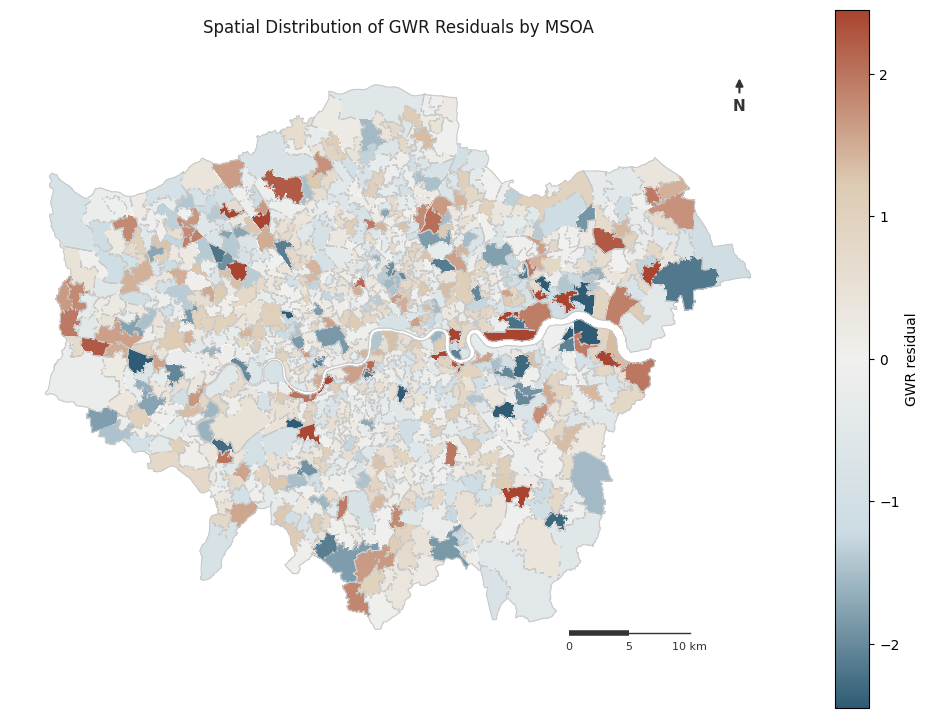

In [26]:
residual_limit = float(
    np.nanpercentile(
        np.abs(
            gwr_result_gdf[
                "gwr_residual"
            ]
        ),
        98,
    )
)

if (
    not np.isfinite(
        residual_limit
    )
    or residual_limit <= 0
):
    residual_limit = float(
        np.nanmax(
            np.abs(
                gwr_result_gdf[
                    "gwr_residual"
                ]
            )
        )
    )

residual_norm = TwoSlopeNorm(
    vmin=-residual_limit,
    vcenter=0,
    vmax=residual_limit,
)

fig, ax = plt.subplots(
    figsize=(10, 10),
    facecolor="#FFFFFF",
)

gwr_result_gdf.plot(
    column="gwr_residual",
    cmap=coefficient_cmap,
    norm=residual_norm,
    legend=True,
    linewidth=0,
    edgecolor="none",
    antialiased=False,
    ax=ax,
    legend_kwds={
        "label": "GWR residual",
        "shrink": 0.72,
    },
    zorder=5,
)

remove_polygon_seams(ax)
add_map_boundaries(ax)

ax.set_title(
    "Spatial Distribution of GWR Residuals by MSOA",
    pad=18,
    color="#1A1A1A",
)

ax.axis("off")

add_scale_bar(ax)
add_north_arrow(ax)

save_figure(
    "fig06e_gwr_residuals.png"
)

### 10.6 Local condition number

C:\Users\YOLO\AppData\Local\Temp\ipykernel_28912\711361618.py:29: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  ].boundary.plot(


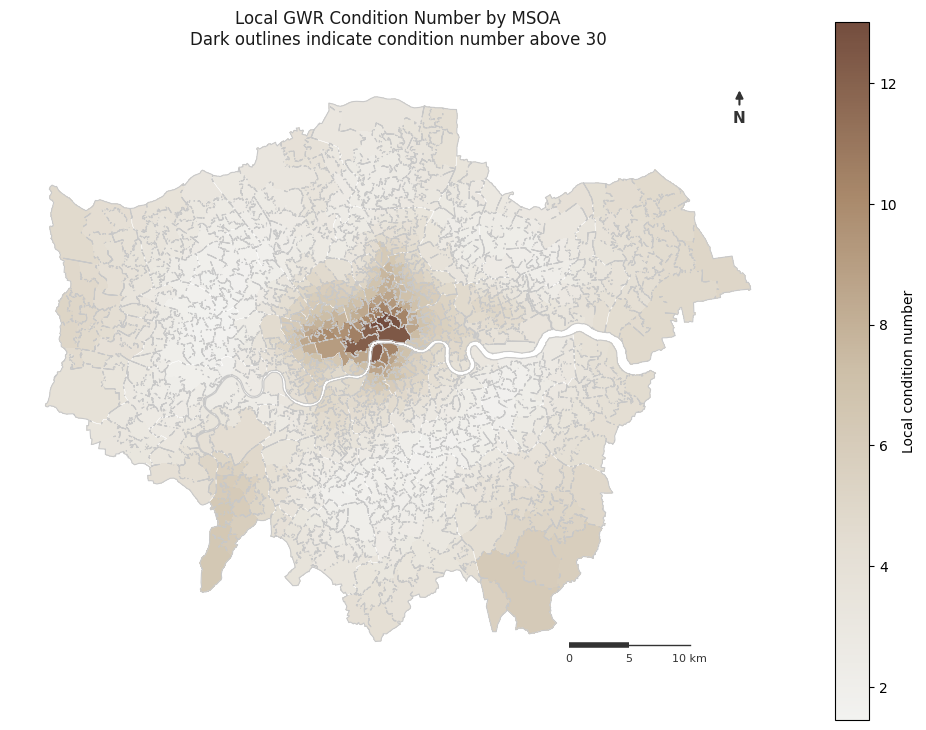

In [27]:
fig, ax = plt.subplots(
    figsize=(10, 10),
    facecolor="#FFFFFF",
)

gwr_result_gdf.plot(
    column="gwr_condition_number",
    cmap=condition_cmap,
    legend=True,
    linewidth=0,
    edgecolor="none",
    antialiased=False,
    ax=ax,
    legend_kwds={
        "label": (
            "Local condition number"
        ),
        "shrink": 0.72,
    },
    zorder=5,
)

remove_polygon_seams(ax)

gwr_result_gdf.loc[
    gwr_result_gdf[
        "gwr_condition_number_gt30"
    ]
].boundary.plot(
    ax=ax,
    color="#333333",
    linewidth=0.35,
    zorder=11,
)

add_map_boundaries(ax)

ax.set_title(
    "Local GWR Condition Number by MSOA\n"
    "Dark outlines indicate condition number above 30",
    pad=18,
    color="#1A1A1A",
)

ax.axis("off")

add_scale_bar(ax)
add_north_arrow(ax)

save_figure(
    "fig06f_gwr_local_condition_number.png"
)

### 10.7 Corrected local significance maps

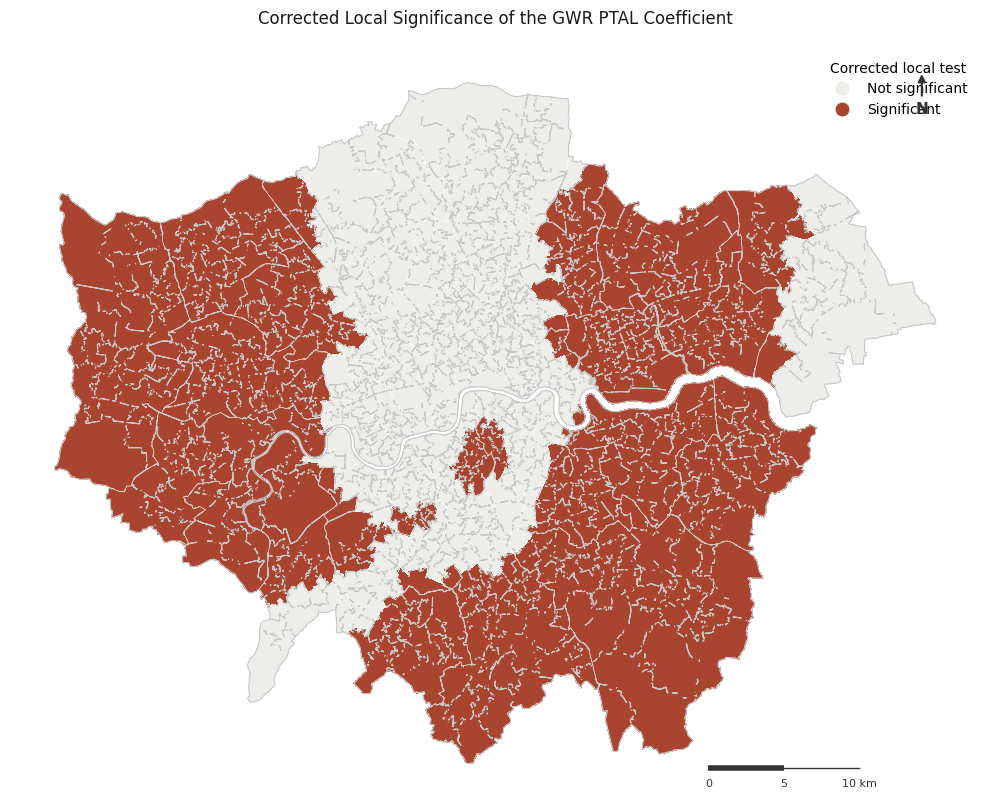

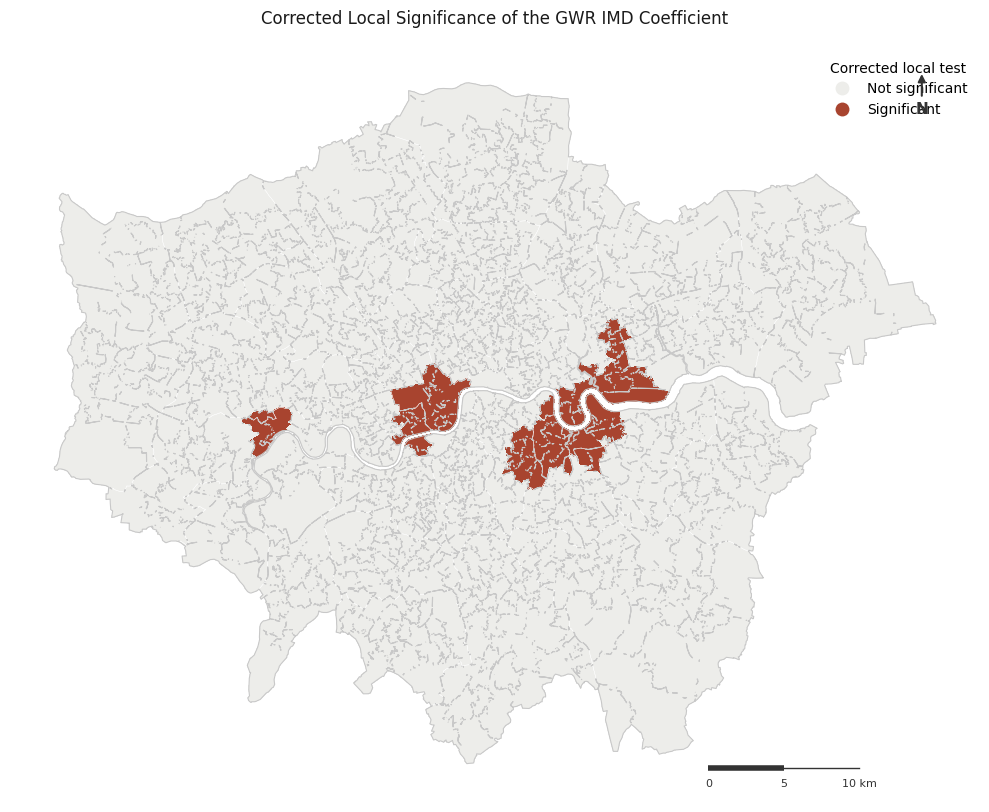

In [28]:
plot_significance_surface(
    significance_column="gwr_sig_ptal",
    title=(
        "Corrected Local Significance of the GWR PTAL Coefficient"
    ),
    filename=(
        "fig06g_gwr_ptal_significance.png"
    ),
)

plot_significance_surface(
    significance_column="gwr_sig_imd",
    title=(
        "Corrected Local Significance of the GWR IMD Coefficient"
    ),
    filename=(
        "fig06h_gwr_imd_significance.png"
    ),
)

## 11. Export the final GWR dataset

In [29]:
GWR_GPKG_PATH = (
    OUTPUT_DIR
    / "06_gwr_results.gpkg"
)

GWR_CSV_PATH = (
    OUTPUT_DIR
    / "06_gwr_results.csv"
)

write_geopackage(
    gwr_result_gdf,
    GWR_GPKG_PATH,
    layer="gwr_results",
)

gwr_result_gdf.drop(
    columns="geometry"
).to_csv(
    GWR_CSV_PATH,
    index=False,
)

print(
    "GeoPackage:",
    GWR_GPKG_PATH,
)

print(
    "CSV:",
    GWR_CSV_PATH,
)

print(
    "Figures:",
    FIG_DIR,
)

GeoPackage: outputs\06_gwr_results.gpkg
CSV: outputs\06_gwr_results.csv
Figures: outputs\figures


## 12. Automatic interpretation check

This cell is designed as a diagnostic prompt, not as dissertation-ready prose. Review the maps and tables before using any statement in the thesis.

In [30]:
ols_row = (
    model_comparison
    .loc[
        model_comparison[
            "model"
        ] == "Global OLS"
    ]
    .iloc[0]
)

gwr_row = (
    model_comparison
    .loc[
        model_comparison[
            "model"
        ] == "GWR"
    ]
    .iloc[0]
)

aicc_change = (
    gwr_row[
        "aicc"
    ]
    - ols_row[
        "aicc"
    ]
)

r2_change = (
    gwr_row[
        "r_squared"
    ]
    - ols_row[
        "r_squared"
    ]
)

moran_change = (
    gwr_residual_moran.I
    - ols_residual_moran.I
)

ptal_summary = (
    coefficient_summary
    .loc[
        coefficient_summary[
            "parameter"
        ] == "Accessible PTAL share"
    ]
    .iloc[0]
)

imd_summary = (
    coefficient_summary
    .loc[
        coefficient_summary[
            "parameter"
        ] == "Mean IMD score"
    ]
    .iloc[0]
)

condition_share = (
    gwr_result_gdf[
        "gwr_condition_number_gt30"
    ]
    .mean()
)

interpretation_lines = [
    (
        "Selected adaptive bandwidth: "
        f"{int(round(selected_bandwidth))} MSOAs."
    ),
    (
        "GWR minus OLS AICc: "
        f"{aicc_change:.3f}. "
        "A negative value favours GWR after accounting for model complexity."
    ),
    (
        "Change in global R-squared from OLS to GWR: "
        f"{r2_change:.3f}."
    ),
    (
        "Change in residual Moran's I from OLS to GWR: "
        f"{moran_change:.3f}. "
        "A negative value indicates reduced residual clustering."
    ),
    (
        "PTAL local coefficient range: "
        f"{ptal_summary['minimum']:.3f} to "
        f"{ptal_summary['maximum']:.3f}; "
        f"{ptal_summary['corrected_significant_share']:.1%} "
        "of MSOAs meet the corrected local significance threshold."
    ),
    (
        "IMD local coefficient range: "
        f"{imd_summary['minimum']:.3f} to "
        f"{imd_summary['maximum']:.3f}; "
        f"{imd_summary['corrected_significant_share']:.1%} "
        "of MSOAs meet the corrected local significance threshold."
    ),
    (
        "Share of MSOAs with local condition number above 30: "
        f"{condition_share:.1%}."
    ),
]

print(
    "\n".join(
        f"- {line}"
        for line in interpretation_lines
    )
)

with open(
    OUTPUT_DIR
    / "06_gwr_interpretation_check.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(
        "\n".join(
            interpretation_lines
        )
    )

- Selected adaptive bandwidth: 124 MSOAs.
- GWR minus OLS AICc: -91.535. A negative value favours GWR after accounting for model complexity.
- Change in global R-squared from OLS to GWR: 0.195.
- Change in residual Moran's I from OLS to GWR: -0.132. A negative value indicates reduced residual clustering.
- PTAL local coefficient range: -0.169 to 1.408; 54.8% of MSOAs meet the corrected local significance threshold.
- IMD local coefficient range: -0.355 to 0.714; 6.4% of MSOAs meet the corrected local significance threshold.
- Share of MSOAs with local condition number above 30: 0.0%.


## 13. Output inventory

### Main model tables

- `06_gwr_bandwidth.csv`
- `06_ols_gwr_model_comparison.csv`
- `06_ols_gwr_residual_morans_i.csv`
- `06_gwr_local_coefficient_summary.csv`
- `06_gwr_local_collinearity_summary.csv`

### Main spatial outputs

- `06_gwr_results.gpkg`
- `fig06a_gwr_ptal_coefficient.png`
- `fig06b_gwr_imd_coefficient.png`
- `fig06d_gwr_local_r2.png`
- `fig06e_gwr_residuals.png`
- `fig06f_gwr_local_condition_number.png`

### Reproducibility checks

1. Does GWR produce a meaningfully lower AICc than OLS?
2. Does GWR reduce residual Moran's I, and does the residual pattern remain significant?
3. Do the PTAL or IMD coefficients change sign across London?
4. Are the spatially varying coefficient surfaces supported by the optional Monte Carlo test?
5. Are apparent local patterns concentrated in areas with high condition numbers or high local VIFs?
6. Which boroughs or named development areas correspond to the strongest and weakest local relationships?
7. Do the maps reveal interpretable geography, or mostly smooth variation produced by the kernel?

Do not describe GWR as proving causation. If the local surfaces are unstable, weakly significant or strongly collinear, report that result directly rather than forcing a local narrative.